# **Initialization and Dataset Download**

In [1]:
# Install the Hugging Face Transformers library quietly
# This library provides pretrained deep learning NLP models like BERT and GPT

!pip install transformers --quiet
!pip install opendatasets --quiet
# Install the opendatasets library quietly
# This library helps download datasets easily from Kaggle and other sources
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadrr
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 5.29MB/s]


# **Imports**
Lets start by getting all our imports, keep in mind that PyTorch is not automatically detects and trains on GPU, you have to tell it to use cuda.

In [2]:
# Import PyTorch (main deep learning library)
import torch

# nn module contains all neural network building blocks (layers, loss functions, etc.)
import torch.nn as nn

# Adam optimizer is used to update model weights during training efficiently
from torch.optim import Adam

# AutoTokenizer automatically converts text into numbers using a pre-trained model tokenizer
# AutoModel loads a pre-trained transformer model (like BERT)
from transformers import AutoTokenizer, AutoModel

# Dataset and DataLoader help us create and load data in batches for training
from torch.utils.data import Dataset, DataLoader

# Splits dataset into training and testing parts
from sklearn.model_selection import train_test_split

# Used to measure model performance (accuracy of predictions)
from sklearn.metrics import accuracy_score

# Used to plot graphs (like training loss vs epochs)
import matplotlib.pyplot as plt

# pandas is used for loading and handling dataset (like Excel tables)
import pandas as pd

# numpy is used for mathematical operations on arrays
import numpy as np


# Check if GPU is available
# CUDA = NVIDIA GPU support for faster training
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Print which device will be used for training (GPU or CPU)
print("Available Device is: ", device)

Available Device is:  cuda


In [3]:
data_df = pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json", lines = True)

In [4]:
data_df.shape

(26709, 3)

# 2. Dataset
Now lets read the dataset, this lab was developed by Google Colab, so dataset downloaded and read from the path shown below. We will be reading the dataset using pandas `read_json` function, then we will remove the nulls/missing data from our dataframe as a filteration process, keep in mind that this process is essential as missing data will stop the code from training. You can skip dropping the missing values if you are 100% sure that there are no missing values in your data. After that we printed the dataset shape and we used the `head()` function to visualize the first 5 rows, this step is optional as it just allows us to see the first 5 rows and will not affect the training process.

In [5]:
data_df.dropna(inplace= True)
data_df.drop_duplicates(inplace=True)
print(data_df.shape)
data_df.drop(['article_link'],inplace= True, axis=1)
data_df.head()

(26708, 3)


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


# 3. Data Splitting
Now we will split our data into the following:

*   Training Size 70%
*   Validation Size 15%
*   Testing Size 15%

We will do this by splitting our data twice using the `train_test_split` function in `sklearn` the function takes inputs, outputs and the testing size. After that we will print the training, validation and testing shapes and sizes.


In [6]:
# Original Dataset
#         |
#         |---- 70% → Training Set
#         |
#         |---- 30%
#                  |
#                  |---- 15% → Validation Set
#                  |
#                  |---- 15% → Test Set


X_train, X_test, y_train, y_test = train_test_split(np.array(data_df["headline"]), np.array(data_df["is_sarcastic"]), test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)


# X_train => training headline
# Y_train => training labels
# X_test => temporary testing headlines
# y_test => temporary testing labels


# here X is np.array(data_df["headline"]) and Y is np.array(data_df["is_sarcastic"])

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)



# IN 2ND STEP ; 30 % DATA WAS IN XTEST/YTEST AND NOW WE SPLIT THAT 30 INTO 15-VALIDATION AND 15-TESTING.


In [7]:
print("Training set is: ", X_train.shape[0], "which is ", round(X_train.shape[0]/data_df.shape[0],4) * 100, "%" )
print("Validation set is: ", X_val.shape[0], "which is ", round(X_val.shape[0]/data_df.shape[0],4) * 100, "%" )
print("Testing set is: ", X_test.shape[0], "which is ", round(X_test.shape[0]/data_df.shape[0],4) * 100, "%" )

Training set is:  18695 which is  70.0 %
Validation set is:  4006 which is  15.0 %
Testing set is:  4007 which is  15.0 %


# 4. Download Model and tokenizer
In the next cell, we will download the model `bert-base-uncased` and its tokenizer using the function `from_pretrained`. Make sure that if you use any model on huggingface or any transformer or pretrained model, use its own tokenizer, if you use any tokenizer with any model the results will be very bad as it wasn't designed for that model


.

BERT is a pretrained transformer-based deep learning NLP model created by Google that understands language using both left and right context of words, making it powerful for tasks like sentiment analysis, sarcasm detection, and text classification. Since neural networks cannot understand raw text directly, a tokenizer is used first to convert text into smaller pieces called tokens and then into numerical IDs that the model can process. AutoTokenizer.from_pretrained("bert-base-uncased") automatically downloads and loads the correct tokenizer and vocabulary for the BERT model, while AutoModel.from_pretrained("bert-base-uncased") downloads the pretrained BERT neural network along with its learned weights. The term "bert-base-uncased" means using the base-sized BERT model that converts all text to lowercase. The overall pipeline is: text → tokenizer → token IDs → BERT → embeddings/features → prediction layer, where BERT generates meaningful vector representations (embeddings) of language that help the model understand context and meaning for downstream tasks like sarcasm detection.




In [8]:
# Load the tokenizer for the pretrained BERT model
# The tokenizer converts text into tokens and numerical IDs
# "bert-base-uncased" means:
#   - bert       -> use BERT architecture
#   - base       -> smaller version of BERT
#   - uncased    -> convert all text to lowercase

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


# Load the pretrained BERT neural network model
# The model has already been trained on huge English text datasets
bert_model = AutoModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 5. Dataset Object
Now we will create the dataset object. This part is not complex but its a bit tricky. We need to convert our dataset to PyTorch `Dataset` object as it will be more efficient during training, you can use the dataset as its, but lets keep things professional and efficient. First we define our class that will be taking the main `Dataset` class with the concept of inheritance. Let's make the concept simpler. There is a big class that PyTorch, this class has several functions inside it, we will recreate that class and modify some functions to match our needs.

In the cell below, we rebuilt the `constructor` function which is `__init__`. We put `X` and `Y` as a parameters to this function which are the inputs and outputs respectively, then inside the function we define the tokenized inputs using the tokenizer function and converting the outputs to tensors. Additionally, we moved all our data to cuda device. Keep in mind that we set `return_tensors` as `pt` which means return pytorch tensors, other option would be `tf` which is tensorflow tensors. Most of the existing transformers now don't support tensorflow. Then we modified the `__len__` and the `__getitem__` to match our needs which gets the specific length/shape of the data, and the data of specific row in our data respectively.

.

A tensor is the main data structure used in deep learning frameworks like PyTorch and can be thought of as an advanced multidimensional array that stores numerical data in forms like scalars, vectors, matrices, or higher-dimensional arrays. Neural networks cannot process text or raw data directly, so everything must be converted into tensors for mathematical computation, GPU acceleration, matrix operations, and gradient calculations during training. torch.float32 is a datatype in PyTorch that stores tensor values as 32-bit floating-point decimal numbers, which is the standard format used in deep learning because neural networks perform continuous decimal-based calculations such as probabilities, weights, activations, and gradients.






In [9]:
# Create a custom dataset class by inheriting from PyTorch Dataset
class dataset(Dataset):

    # Constructor function
    # X = input text data
    # Y = labels
    def __init__(self, X, Y):

        # Tokenize every sentence in X using BERT tokenizer
        self.X = [

            # Convert text into BERT-compatible tokens
            tokenizer(
                x,

                # Maximum sequence length
                max_length = 100,

                # Cut tokens if sentence exceeds max_length
                truncation = True,

                # Add padding tokens if sentence is shorter
                padding = 'max_length',

                # Return PyTorch tensors
                return_tensors='pt'

            )

            # Move tensors to CPU/GPU device
            .to(device)

            # Repeat for every sentence in X
            for x in X
        ]

        # Convert labels into PyTorch float tensors
        # Then move them to CPU/GPU
        self.Y = torch.tensor(
            Y,
            dtype = torch.float32
        ).to(device)


    # Return total number of samples in dataset
    def __len__(self):
        return len(self.X)


    # Return one sample and its label using index
    def __getitem__(self, index):
        return self.X[index], self.Y[index]


# Create training dataset object
training_data = dataset(X_train, y_train)

# Create validation dataset object
validation_data = dataset(X_val, y_val)

# Create testing dataset object
testing_data = dataset(X_test, y_test)

# 6. Training Hyper Parameters
Now we are setting the training hyperparameters, we defined some variables which are the batch size, number of training epochs and learning rate.

BATCH_SIZE = 32 means the model processes 32 training samples at a time before updating its weights, which improves memory efficiency and training speed. EPOCHS = 25 means the model will go through the entire training dataset 25 times so it can gradually learn patterns from the data. LR = 1e-4 sets the learning rate to 0.0001, controlling how much the model updates its weights during training; small learning rates are commonly used when fine-tuning pretrained models like BERT to keep training stable and preserve learned language knowledge.

In [10]:
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-4

# 7. Data Loaders
This concept may seem complicated, but its very easy, PyTorch provides a class called `DataLoader` which allows us to create objects of it to simplify the training.

`Dataloader` is an object that we can loop through it to train according to batches. When we start training, we loop through epochs, if you skip the batch size it means that the amount of training data in one batch is equal to the complete amount of training data, this method is not efficient and in most of the cases you need to train through using batches. `Dataloader` allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the shuffle to randomize the data and then you can loop through it in each epoch to train normally.

In the next cell, we defined a dataloader for each of our data (training, validation and testing).

In [11]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle= True)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle= True)

# 8. Model Class
Creating a model in PyTorch seems not very straight forward in the beggining, but if you understand how machine learning and deep learning works, it will be easy for you to understand PyTorch structure easily.

In the next cell we define a new class `MyModel` that inherits from `nn.Module` like we did for the dataset. Remember, in simple terms, we want to redefine some functions in the class to match our needs. In the constructor which is `__init__` and we give it the bert model. Then `super(MyModel, self).__init__()` This line calls the constructor of the parent class `nn.Module` to ensure it's properly initialized. Which means we have the original constructor together with our part of it!

Then, we create our layers, we will have in addition to bert layers a dropout layer, 2 linear (dense) layers and a sigmoid activation function since we are dealing with Binary Classification Problem. Keep in mind that we have to mention for each layer the number of inputs and outputs except for the dropout layer. Linear 2 in this case is the output layer without the activation.

In the function forward, this function is the forward propagation of the model, how is the data flowing inside the model from the input to the output. This means we can control this completely. That's how PyTorch is so customizable! In the below cell, we define the flow as follows, starting by Bert followed by a linear layer then dropout, another linear and finally the sigmoid.

.

CHATgpt :::
This code defines a custom PyTorch neural network model for sarcasm detection using a pretrained BERT model as the feature extractor. The input text embeddings generated by BERT (768-dimensional vectors) are passed through additional fully connected (Linear) layers to learn sarcasm-specific patterns. A Dropout layer randomly disables some neurons during training to reduce overfitting, and the final layer outputs a single value representing sarcasm probability. The Sigmoid activation function converts this output into a value between 0 and 1 for binary classification. The forward() function defines how tokenized input data flows through BERT and the custom layers to produce predictions.

In [12]:
# Create a custom neural network model
# Inherit from PyTorch nn.Module

class MyModel(nn.Module):

  def __init__(self,bert):              # Constructor function


    super(MyModel,self).__init__()      # Initialize parent nn.Module class

    self.bert = bert                    # Store pretrained BERT model
    self.dropout = nn.Dropout(0.25)     # Dropout layer | Randomly disables 25% neurons during training | Helps prevent overfitting
    self.linear1 = nn.Linear(768,384)   # First fully connected layer | Input size: 768 (BERT embedding size) | Output size: 384
    self.linear2 = nn.Linear(384,1)     # Second fully connected layeR |  Reduces 384 features into 1 final output
    self.sigmoid = nn.Sigmoid()         # Sigmoid activation functioN | Converts output into probability between 0 and 1 | EX: 0.92 => SARCASM | Ex : 0.21 => Not sarcasm


  def forward(self,input_ids, attention_mask):    # Defines forward pass of the neural network

    # Pass tokenized text through BERT
    # [0][:,0] extracts CLS token embedding
    # CLS token represents entire sentence meaning
    pooled_output = self.bert(input_ids,attention_mask, return_dict = False)[0][:,0]

    output = self.linear1(pooled_output)  # Pass BERT embeddings through first linear layer
    output = self.dropout(output)         # Apply dropout regularization
    output = self.linear2(output)         # Pass through second linear layer
    output = self.sigmoid(output)         # Convert output into probability
    return output                         # Return final prediction



# 9. Pretraining
This part is very small, the first 2 lines in the next cell we are freezing the bert model weight. Remember that Bert is a pretrained transformer that has been already trained on a huge amount of data. We want to fine-tune it on our task and not training from scratch. The model already has good amount of "Knowledge". Then we create an object of our model that we defined previously giving to it Bert and we mode it to Cuda.

.

GPT EXPLAINATION :::: This code freezes all pretrained BERT parameters by setting requires_grad = False, which prevents BERT’s weights from updating during training. This means BERT acts as a fixed feature extractor while only the custom classification layers (linear1 and linear2) learn sarcasm-specific patterns. The for loop iterates through every parameter inside BERT and disables gradient computation to reduce training time, memory usage, and overfitting risk. Then MyModel(bert_model) creates the custom neural network containing the frozen BERT model and additional layers, and .to(device) moves the entire model to the selected device (GPU or CPU) for computation

In [13]:
# Loop through every parameter inside pretrained BERT
for param in bert_model.parameters():

  param.requires_grad = False  # Freeze the parameter | No gradients will be computed | BERT weights will NOT update during training


model = MyModel(bert_model)  # Create object of custom model class |  Pass pretrained BERT model into MyModel
model = model.to(device)  # Move entire model to GPU/CPU device

# 10. Loss and Optimizer
In this cell, we define our loss function as Binary Cross Entropy which is `nn.BCELoss` in PyTorch. Then, we will define the optimizer and we will give it the model parameters/weights which will be the parameters of the new layers we added as those are the parameters we will want to train.

Input
  =>
Model prediction
  =>
BCELoss measures error
  =>
Backpropagation computes gradients
  =>
Adam optimizer updates weights

In [14]:
# Binary Cross Entropy Loss function
# Used for binary classification problems
# Measures how wrong model predictions are
criterion = nn.BCELoss()


# Adam optimizer
# Updates trainable model weights using gradients
# model.parameters() gives optimizer access to trainable parameters (weights and bias)
# lr sets learning rate
optimizer = Adam(model.parameters(), lr = LR)

# 11. Training Loop
Now comes the exciting part. As we mentioned several times, nothing is complex here if you know how deep learning works. You just need to know PyTorch syntax. We start by initializing the for loop with the specified number of epochs. But before that we define 4 lists and inside the loop we define another 4 variables.


### Variables:
*   `total_acc_train`: here we will keep tracking of the training accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch.

*   `total_loss_train`: here we will keep tracking of the training loss progress during each epoch, we calculate the accuracy during the batch size and we use the loss value to optimize and modify the model parameters.

*   `total_acc_val`: here we will keep tracking of the validation accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch and help us know if there is any overfitting.

*   `total_loss_val`: here we will keep tracking of the validation loss progress during each epoch, we calculate the accuracy during the batch size.

### Lists:
*    `total_acc_train_plot`: We append the losses of the training accuracy to visualize them at the end.

*    `total_loss_train_plot`: We append the losses of the training to visualize them at the end.

*    `total_acc_validation_plot`: We append the losses of the validation accuracy to visualize them at the end.

*    `total_loss_validation_plot`: We append the losses of the validation to visualize them at the end.

## - Training
Then, we start to loop through the training dataloaders, we use the `enumerate` functionality to loop through data and indices at the same time. We are not using the indices here, but lets kept it just if you want to try different stuff with the loop or debug. In the second loop, we start by getting our data from the data loader, then we move the inputs and labels to the cuda device. We allow the model to make a prediction or what is called forward propagation, then we get the output of the model and compare it with our original output using the loss criteration, we add the loss amount to `total_loss_train`. Additionally, we get the accuracy by comparing the correct batch with the predicted batch and we add it to the `total_acc_train`. Then we do the `batch_loss.backward()` which makes the backpropagation and we use the optimizer to do a step on the weights using `optimizer.step()` and then we reset the optimizer gradients using `optimizer.zero_grad()` which is a very important step that has to be done before proceeding.

## - Validation
After that we exit the batch loop (train dataloader loop) and we start with the validation. Don't forget that we are still in the same epoch. In side that we start by `with torch.no_grad()` which means that we need the model to do predicitons without being trained. We just need to see the validation preformance. Then we do the same steps which are predicting and calculating loss and accuracy and storing these values.

At the end we print after each epoch the epoch number, training loss, training accuracy, validation loss and validation accuracy. We use the printing of "=" signs just for making the printing output looks clean.




.

CHATGPT :::: Summary — What This Entire Code Is Doing

This code is implementing the complete training and validation pipeline for a BERT-based deep learning classification model using PyTorch.

The process starts by looping through the dataset for multiple epochs. During the training phase, batches of tokenized text data are loaded from the train_dataloader. Each batch contains:

tokenized inputs (input_ids and attention_mask)
labels (correct answers)

These inputs are passed into the BERT model to generate predictions. The predictions are compared with the actual labels using a loss function (criterion) to measure how wrong the model is. Then, backpropagation computes gradients, and the optimizer updates the model weights so the model can learn from its mistakes.

At the same time, training accuracy and training loss are continuously accumulated.

After training, the code enters the validation phase using torch.no_grad() so no learning happens. The model predicts outputs for unseen validation data, and validation loss and accuracy are calculated to evaluate how well the model generalizes to new data.

Finally, after every epoch:

training loss
validation loss
training accuracy
validation accuracy

are stored in lists for plotting graphs and printed to monitor model performance.



In [15]:
total_loss_train_plot = []              # store train loss per epoch
total_loss_validation_plot = []         # store val loss per epoch
total_acc_train_plot = []               # store train accuracy per epoch
total_acc_validation_plot = []          # store val accuracy per epoch

for epoch in range(EPOCHS):             # loop over epochs
    total_acc_train = 0                 # reset train accuracy
    total_loss_train = 0                # reset train loss
    total_acc_val = 0                   # reset val accuracy
    total_loss_val = 0                  # reset val loss

    ## Training phase
    for indx, data in enumerate(train_dataloader):  # iterate train batches
        inputs, label = data                         # unpack batch

        inputs = inputs.to(device)                            # move inputs to GPU/CPU
        label = label.to(device)                            # move labels to device

        prediction = model(
            inputs['input_ids'].squeeze(1),          # token ids input
            inputs['attention_mask'].squeeze(1)      # attention mask input
        ).squeeze(1)                                # reshape output

        batch_loss = criterion(prediction, label)  # compute loss

        total_loss_train += batch_loss.item()       # accumulate loss

        acc = ((prediction).round() == label).sum().item()  # batch accuracy
        total_acc_train += acc                      # accumulate accuracy

        batch_loss.backward()                       # BACKPROPAGATION
        optimizer.step()                            # update weights
        optimizer.zero_grad()                      # reset gradients

    ## Validation phase
    with torch.no_grad():                           # disable gradients ; only validation , no updates
        for indx, data in enumerate(validation_dataloader):  # val batches
            inputs, label = data                     # unpack batch

            inputs = inputs.to(device)                        # move inputs
            label = label.to(device)                        # move labels

            prediction = model(
                inputs['input_ids'].squeeze(1),     # token ids
                inputs['attention_mask'].squeeze(1)  # attention mask
            ).squeeze(1)                            # reshape output

            batch_loss_val = criterion(prediction, label)  # val loss
            total_loss_val += batch_loss_val.item()        # accumulate loss

            acc = ((prediction).round() == label).sum().item()  # val acc
            total_acc_val += acc                          # accumulate acc

    # store epoch-wise metrics
    total_loss_train_plot.append(round(total_loss_train/1000, 4))     # avg train loss
    total_loss_validation_plot.append(round(total_loss_val/100, 4))    # avg val loss
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))  # train acc %
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))  # val acc %

    # print epoch summary
    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/100:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)                           # separator line

Epoch no. 1 Train Loss: 0.2576 Train Accuracy: 80.5670 Validation Loss: 0.4787 Validation Accuracy: 83.3500
Epoch no. 2 Train Loss: 0.2101 Train Accuracy: 84.6750 Validation Loss: 0.4403 Validation Accuracy: 84.3734
Epoch no. 3 Train Loss: 0.1969 Train Accuracy: 85.5897 Validation Loss: 0.4218 Validation Accuracy: 84.9725
Epoch no. 4 Train Loss: 0.1900 Train Accuracy: 85.9588 Validation Loss: 0.4193 Validation Accuracy: 85.4468
Epoch no. 5 Train Loss: 0.1860 Train Accuracy: 86.3332 Validation Loss: 0.4150 Validation Accuracy: 85.6465
Epoch no. 6 Train Loss: 0.1826 Train Accuracy: 86.5312 Validation Loss: 0.4313 Validation Accuracy: 84.8477
Epoch no. 7 Train Loss: 0.1808 Train Accuracy: 86.7826 Validation Loss: 0.4163 Validation Accuracy: 85.7963
Epoch no. 8 Train Loss: 0.1786 Train Accuracy: 86.8628 Validation Loss: 0.4119 Validation Accuracy: 85.4219
Epoch no. 9 Train Loss: 0.1769 Train Accuracy: 86.8414 Validation Loss: 0.4013 Validation Accuracy: 86.1957
Epoch no. 10 Train Loss: 0.1

# WHAT DO I LEARN FROM THE ABOVE OUTPUT CELL?
Your BERT model learned successfully during training. At the beginning, both training accuracy and validation accuracy were around 83–84%, which means the model initially understood some patterns but still made many mistakes. As epochs increased, the training loss steadily decreased from about 0.23 to 0.17, showing that the model was learning and reducing its errors. At the same time, validation accuracy improved to around 86%, meaning the model was also performing well on unseen data, not just memorizing the training set. Since training accuracy (~87%) and validation accuracy (~86%) stayed close to each other, this indicates that the model did not suffer from severe overfitting and generalized reasonably well. Around epochs 10–15, the improvements became very small, showing that the model had already learned most useful patterns and further training gave little additional benefit. Small fluctuations in validation loss after later epochs suggest slight overfitting may have started, but it was not serious. Overall, the output shows a stable and successful BERT fine-tuning process with good learning behavior, decreasing loss, improving accuracy, and decent generalization performance on validation data.

# 12. Testing
Now in this section, we will be testing our model, we will start the code by ```with torch.no_grad():``` which means that we are telling PyTorch that we don't want to train the model we will be using it only for testing. Then we will declare initial loss and accuracy as zeros, we will start by looping through the testing dataloader like we did before during training. Inside the loop, we got our data and we moved it to our GPU (cuda) and then we ran our model on the data and we got the predictions. After that we get the loss and then we add it to our overall loss, we do the same for accuracy, and finally we print the accuracy.



In [16]:
with torch.no_grad():
  total_loss_test  = 0
  total_acc_test = 0

  for indx, data in enumerate(testing_dataloader):

    inputs,label = data
    inputs = inputs.to(device)
    label = label.to(device)

    prediction = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)

    batch_loss_val = criterion(prediction, label)
    total_loss_test += batch_loss_val.item()

    acc = ((prediction).round() == label).sum().item()
    total_acc_test += acc

print(f"Accuracy score is: {round((total_acc_test/X_test.shape[0]) * 100, 2)} %")

Accuracy score is: 85.33 %


# 13. Plotting and Visualizations (Optional)
The results may not be very good, feel free to play with the layers, hyperparameters and text filteration to achieve better performance!

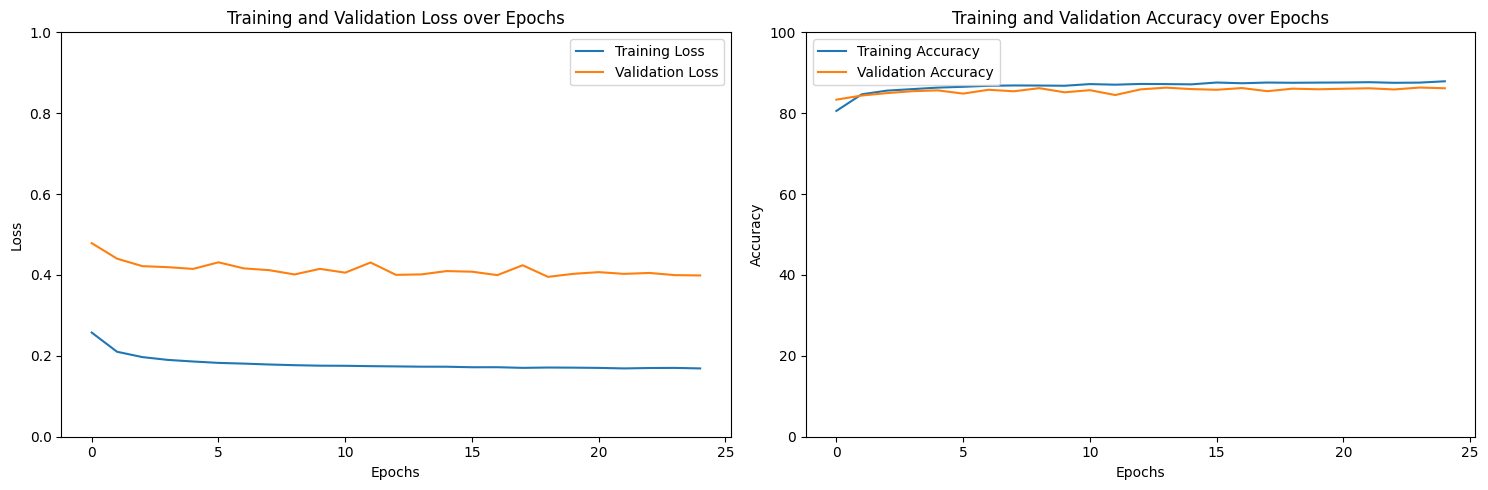

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 1])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

#Saving the model

In [18]:
# Save model weights
torch.save(model.state_dict(), "sarcasm_model.pt")

# Save tokenizer
tokenizer.save_pretrained("tokenizer/")

('tokenizer/tokenizer_config.json', 'tokenizer/tokenizer.json')

TEST NEW HEADLINES

In [19]:
# ============== TEST NEW HEADLINES (Inference) ==============

print("✅ Model is ready for testing!\n")

while True:
    headline = input("Enter a news headline (or type 'exit' to quit): ")

    if headline.lower() == 'exit':
        print("Goodbye!")
        break

    if not headline.strip():
        print("Please enter a valid headline.\n")
        continue

    # Tokenize
    inputs = tokenizer(headline,
                       max_length=100,
                       truncation=True,
                       padding='max_length',
                       return_tensors="pt").to(device)

    # Predict
    with torch.no_grad():
        prob = model(inputs['input_ids'].squeeze(1),
                     inputs['attention_mask'].squeeze(1)).squeeze(1).item()

    if prob > 0.5:
        print(f"😏 **Sarcastic** ({prob:.1%} confidence)\n")
    else:
        print(f"🙂 **Not Sarcastic** ({prob:.1%} confidence)\n")

✅ Model is ready for testing!

Enter a news headline (or type 'exit' to quit): sexual hot day it is!
🙂 **Not Sarcastic** (3.7% confidence)

Enter a news headline (or type 'exit' to quit): its so cold here this june!
🙂 **Not Sarcastic** (16.2% confidence)

Enter a news headline (or type 'exit' to quit): he killed them like he ate an apple
🙂 **Not Sarcastic** (3.2% confidence)

Enter a news headline (or type 'exit' to quit): its a sarcasm
🙂 **Not Sarcastic** (13.6% confidence)

Enter a news headline (or type 'exit' to quit): today's temparature is 42 degree centigrade I feel like winter 
🙂 **Not Sarcastic** (19.2% confidence)

Enter a news headline (or type 'exit' to quit): Man Lost in Mountain for 24 Hours Ignores Rescuers' Calls Because He Didn’t Recognize the Number
😏 **Sarcastic** (90.6% confidence)

Enter a news headline (or type 'exit' to quit): man gifted his pregnant wife a gold ring, awful she said!
🙂 **Not Sarcastic** (28.7% confidence)

Enter a news headline (or type 'exit' to

In [20]:
# 3. Zip tokenizer folder
!zip -r tokenizer.zip tokenizer

# 4. (Optional) Zip dataset folder
!zip -r dataset.zip news-headlines-dataset-for-sarcasm-detection

# ===================== DOWNLOAD FILES =====================

from google.colab import files

# Download trained model
files.download("sarcasm_model.pt")

# Download tokenizer
files.download("tokenizer.zip")

# Download dataset (optional)
files.download("dataset.zip")

  adding: tokenizer/ (stored 0%)
  adding: tokenizer/tokenizer_config.json (deflated 42%)
  adding: tokenizer/tokenizer.json (deflated 71%)
  adding: news-headlines-dataset-for-sarcasm-detection/ (stored 0%)
  adding: news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset_v2.json (deflated 71%)
  adding: news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>